In [1]:
# 2D FEM (finite element method) modelling on 2 layer 

In [3]:
# Compare 2D FEM modelling with 1D VES sounding with and without complex resistivity values.
# VES is vertical electrical sounding 

In [4]:
# 1D VES looks at ground in layers (like a cake).. it doesnt account for faults 
# 2D FEM takes geological features into account 

In [5]:
import numpy as np

import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert
from pygimli.physics.ves import VESModelling, VESCModelling

In [7]:
scheme = ert.createData(pg.utils.grange(start=1, end=24, dx=1, n=10, log=True),
                        sounding=True)

# 1D VES model (Schlumberger)
# pg.utils.grange is for electrode location specification
# it defines the distance of each electrode from the centre .. starts at 1 m from centre and then goes on till 24m .. 10 electrodes on each side.. log=True means distance is calculated logarithimacally.. we need 
# closer electrodes near the centre 
# sounding is for making it 1D

In [8]:
plc = mt.createWorld(start=[-200, -100], end=[200, 0],
                     layers=[-10], area=[5.0, 500])

(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>,
 <matplotlib.colorbar.Colorbar at 0x2140f3afb10>)

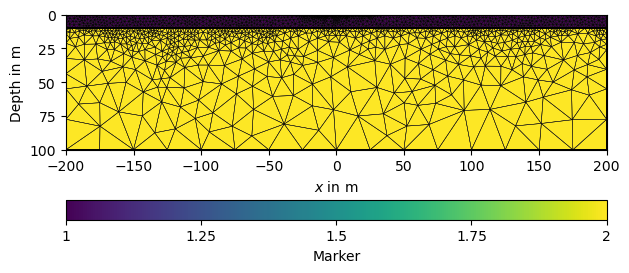

In [10]:
for s in scheme.sensors():
    plc.createNode(s + [0.0, -0.2])

# fwd model
mesh = mt.createMesh(plc, quality=33)

pg.show(mesh, data=mesh.cellMarkers(), label='Marker', showMesh=True)

In [11]:
data = ert.simulate(mesh, res=[[1, 100.0], [2, 1.0]],
                   scheme=scheme, verbose=True)

06/05/26 - 11:14:58 - pyGIMLi - INFO - Calculate geometric factors.


In [13]:
x = pg.x(scheme) # extracts x coordinates 
ab2 = (x[scheme('b')] - x[scheme('a')])/2 # distance of electrodes from centre 
mn2 = (x[scheme('n')] - x[scheme('m')])/2 # 
ves = VESModelling(ab2=ab2, mn2=mn2)

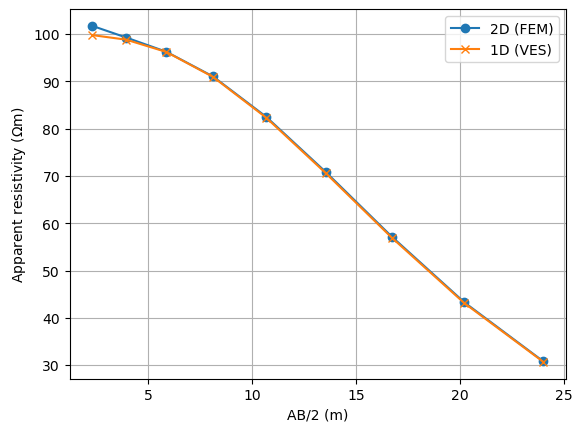

In [15]:
fig, ax = pg.plt.subplots(1, 1)
ax.plot(ab2, data('rhoa'), '-o', label='2D (FEM)')
ax.plot(ab2, ves.response([10.0, 100.0, 1.0]), '-x', label='1D (VES)')
ax.set_xlabel('AB/2 (m)')
ax.set_ylabel('Apparent resistivity ($\Omega$m)')
ax.grid(1)
ax.legend()

In [16]:
# visual rep of measuring the same thing in 2 ways 
# where overlap of 1D and 2D measurement is the place where topography/fault lines dont exist 

In [17]:
# example 2 where topography exists in layers and 1D and 2D models will give different answer 

In [19]:
amps = np.array([100.0, 1.0]) # real resistivity value for 2 layers 
phases = np.array([1.0, 10.0]) # phase between V and i 
res = amps - 1j * amps * np.sin(phases/1000.)
data = ert.simulate(mesh, res=[[1, res[0]], [2, res[1]]],
                   scheme=scheme, verbose=True)

ves = VESCModelling(ab2=ab2, mn2=mn2)
rc = ves.response([10.0, 100.0, 1.0, phases[0]/1000, phases[1]/1000]) #[Thickness1, Rho1, Rho2, Phase1, Phase2].

06/05/26 - 11:20:46 - pyGIMLi - INFO - Complex resistivity values found.


AssertionError: 
Items are not equal to 5 significant digits:
 ACTUAL: 31.57681200212995
 DESIRED: 30.66351249

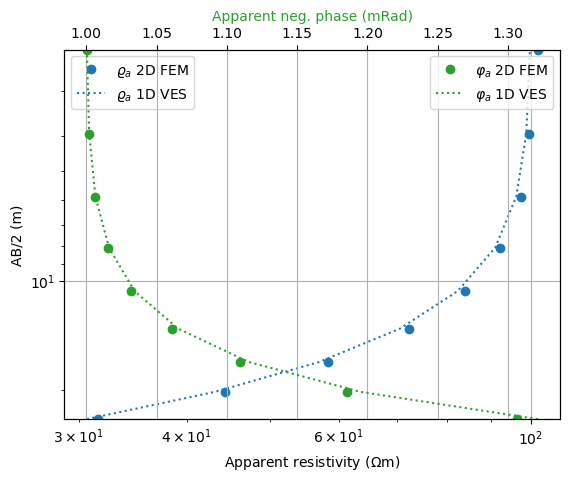

In [20]:
fig, ax = pg.plt.subplots(1, 1)
ves.drawData(ax, pg.cat(data('rhoa') #concatenates 2 arrays 
                        , -data('phia')),
            labels=[r'$\varrho_a$ 2D FEM', r'$\varphi_a$ 2D FEM'],
            marker='o', linestyle='none')
ves.drawData(ax, rc,
             labels=[r'$\varrho_a$ 1D VES', r'$\varphi_a$ 1D VES'],
             marker=None)

np.testing.assert_approx_equal(data('rhoa')[0], 30.66351249, significant=5)
np.testing.assert_approx_equal(-data('phia')[0], 0.00132173865, significant=5)
# 30.6635.. and 0.00132.. are apparent resistivity values for both layers 